In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('/content/cleaned_transactions.csv')

# Quick overview
df.info()
df.describe()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:00
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:00
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:00
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:00
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:00


## Step 3: Univariate Analysis
We explore one variable at a time to understand its distribution and spot unusual patterns.


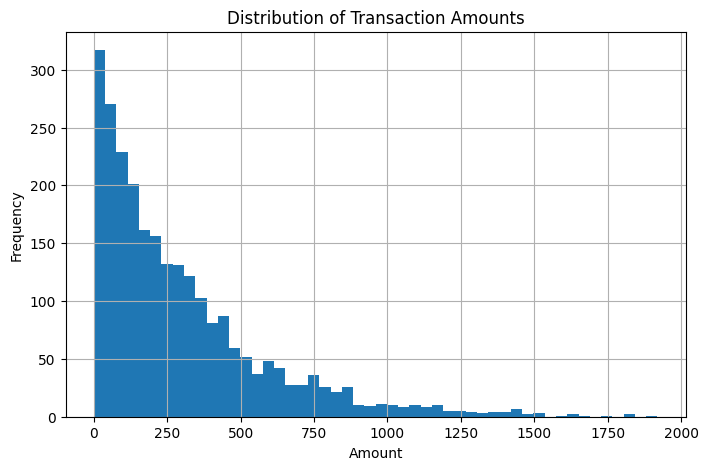

In [4]:
df['TransactionAmount'].hist(bins=50, figsize=(8,5))
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()


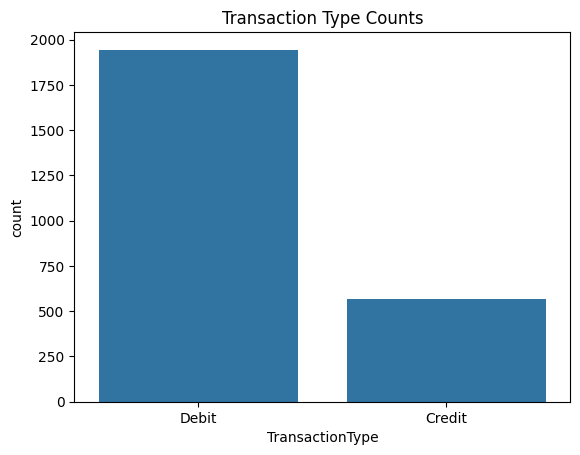

In [5]:
sns.countplot(x='TransactionType', data=df)
plt.title('Transaction Type Counts')
plt.show()


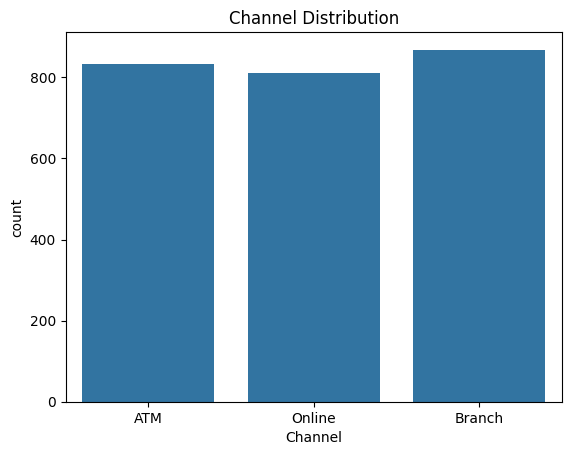

In [6]:
sns.countplot(x='Channel', data=df)
plt.title('Channel Distribution')
plt.show()


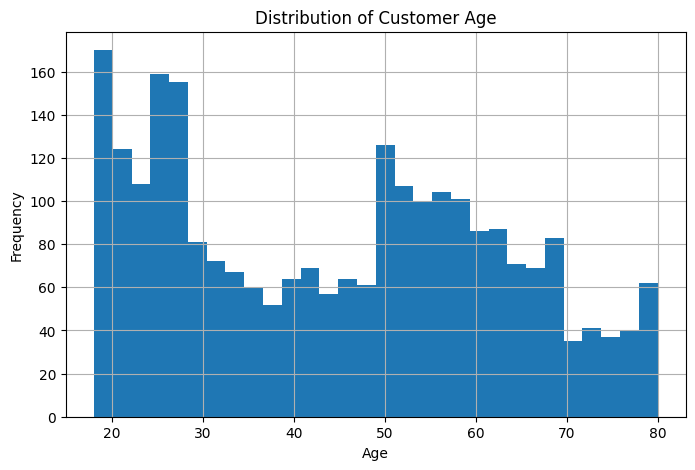

In [7]:
df['CustomerAge'].hist(bins=30, figsize=(8,5))
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


## Step 4: Bivariate Analysis
We compare two variables at a time to see relationships and spot anomalies that may indicate fraud.


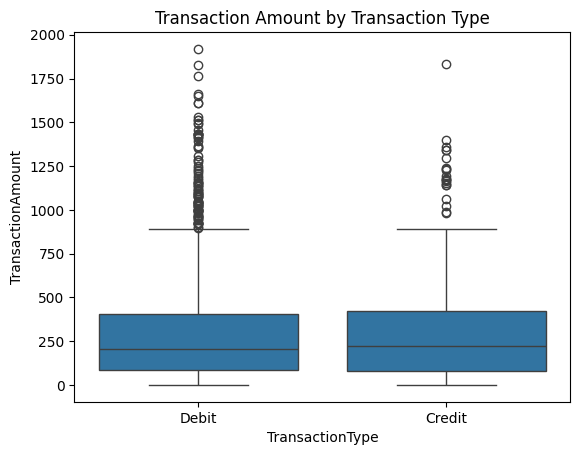

In [8]:
sns.boxplot(x='TransactionType', y='TransactionAmount', data=df)
plt.title('Transaction Amount by Transaction Type')
plt.show()


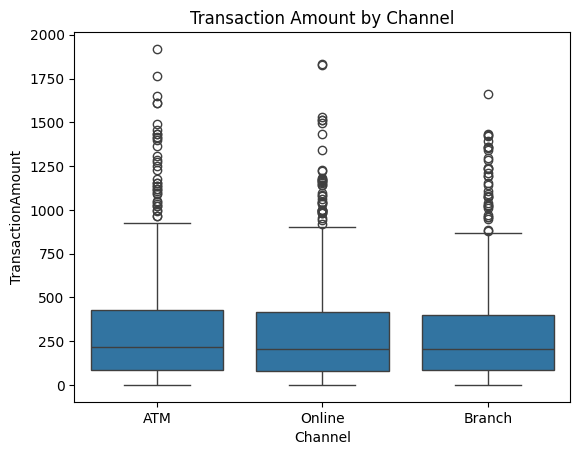

In [9]:
sns.boxplot(x='Channel', y='TransactionAmount', data=df)
plt.title('Transaction Amount by Channel')
plt.show()


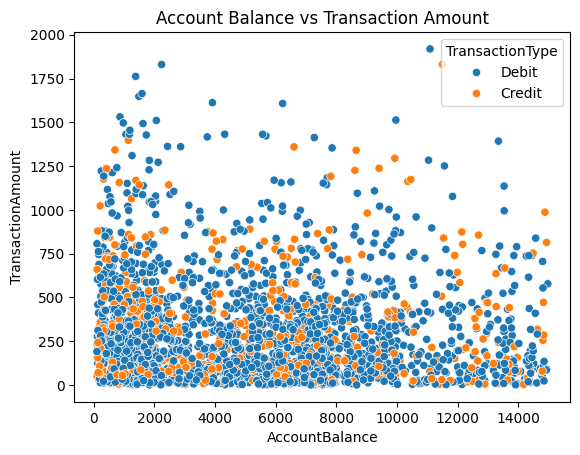

In [10]:
sns.scatterplot(x='AccountBalance', y='TransactionAmount', hue='TransactionType', data=df)
plt.title('Account Balance vs Transaction Amount')
plt.show()


In [11]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['Hour'] = df['TransactionDate'].dt.hour


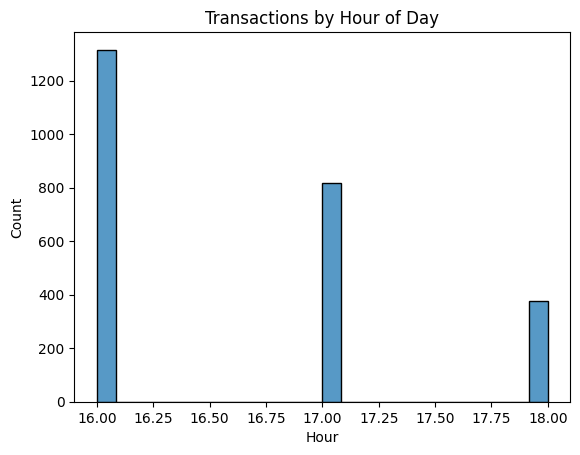

In [12]:
sns.histplot(data=df, x='Hour', bins=24)
plt.title('Transactions by Hour of Day')
plt.show()


In [14]:
df.columns


Index(['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate',
       'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID',
       'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration',
       'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate', 'Hour'],
      dtype='object')

### Findings
- The dataset does not contain a fraud label column.
- EDA was performed on transaction amount, type, channel, age, and time.
- Patterns identified (large amounts, online channel, odd hours) will be used later in Phase 3 when building a fraud detection model.


# Phase 2: Exploratory Data Analysis (EDA) – Findings

### Key Observations
- **Transaction Amounts**  
  - Most transactions are small to medium amounts.  
  - A few very large transactions stand out as potential anomalies.

- **Transaction Types**  
  - Debit transactions are more frequent than credit.  
  - High‑value transactions tend to occur more often in debit type.

- **Channels**  
  - Online transactions show higher variability in amounts compared to branch/ATM.  
  - This could be an important fraud indicator in later modeling.

- **Customer Age**  
  - Majority of customers fall in the 20–70 age range.  
  - Younger customers (students) often transact smaller amounts.

- **Time of Day**  
  - Transactions cluster around business hours, but unusual spikes appear in late evening.  
  - Time‑based features may help in detecting suspicious activity.

### Limitations
- The dataset does **not contain a fraud label column**.  
- Therefore, direct fraud vs. non‑fraud comparisons were not possible in EDA.  
- Identified patterns (large amounts, online channel, odd hours) will be used later in **Phase 3 (modeling)** when building a fraud detection baseline.

### Next Steps
- Engineer new features (e.g., transaction frequency, time since last transaction).  
- Prepare dataset for baseline fraud detection model in Phase 3.  
- Use identified suspicious patterns as candidate predictors of fraud.
